In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/stud.csv')

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

In [5]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [6]:
df.drop_duplicates(inplace = True)

In [7]:
df.shape

(1000, 8)

In [12]:
df = df.T.drop_duplicates().T

In [13]:
df.shape

(1000, 8)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   object
 6   reading score                1000 non-null   object
 7   writing score                1000 non-null   object
dtypes: object(8)
memory usage: 62.6+ KB


In [20]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [21]:
categorical_features = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
numerical_features = ['math score' , 'reading score' , 'writing score']

In [23]:
for i in categorical_features:
    print(df[i].unique())

['female' 'male']
['group B' 'group C' 'group A' 'group D' 'group E']
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
['standard' 'free/reduced']
['none' 'completed']


In [24]:
df.describe()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
count,1000,1000,1000,1000,1000,1000,1000,1000
unique,2,5,6,2,2,81,72,77
top,female,group C,some college,standard,none,65,72,74
freq,518,319,226,645,642,36,34,35


In [25]:
for i in numerical_features:
    df[i] = df[i].astype(int)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int32 
 6   reading score                1000 non-null   int32 
 7   writing score                1000 non-null   int32 
dtypes: int32(3), object(5)
memory usage: 50.9+ KB


*** Adding columns for total score and average score***

In [36]:
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average score'] = (df['total score']/3).round(2)

In [37]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.67
1,female,group C,some college,standard,completed,69,90,88,247,82.33
2,female,group B,master's degree,standard,none,90,95,93,278,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.33
4,male,group C,some college,standard,none,76,78,75,229,76.33


<Axes: xlabel='average score', ylabel='Count'>

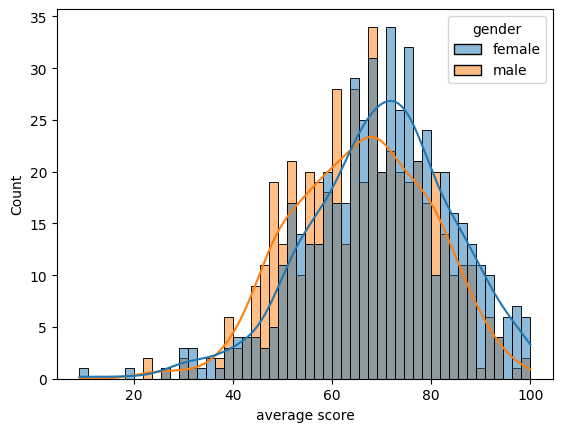

In [40]:
sns.histplot(x = df['average score'] ,kde = True,bins = 50, hue = df['gender'])

<Axes: xlabel='total score', ylabel='Count'>

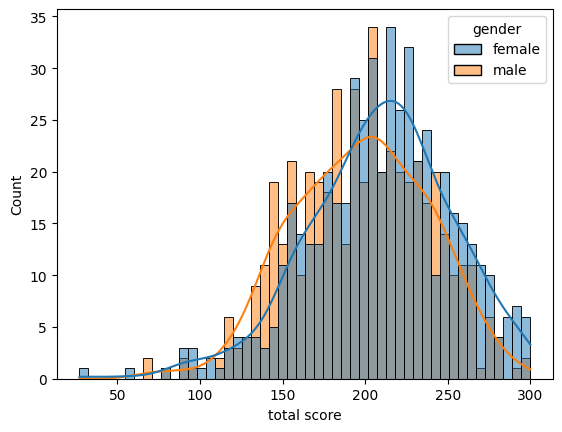

In [42]:
sns.histplot(x = df['total score'] ,bins = 50 , kde = True, hue = df['gender'])

<Axes: xlabel='total score', ylabel='Count'>

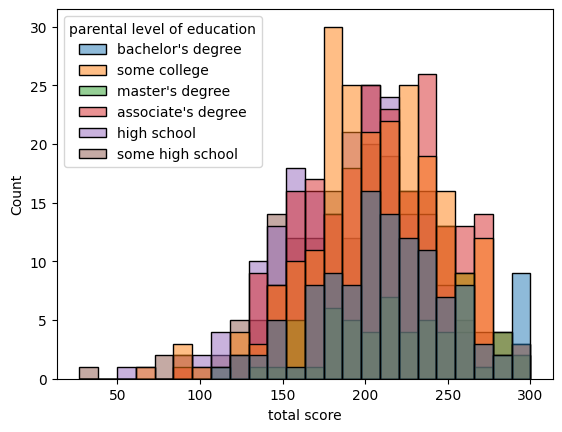

In [43]:
sns.histplot(data = df , x = 'total score' , hue = 'parental level of education')

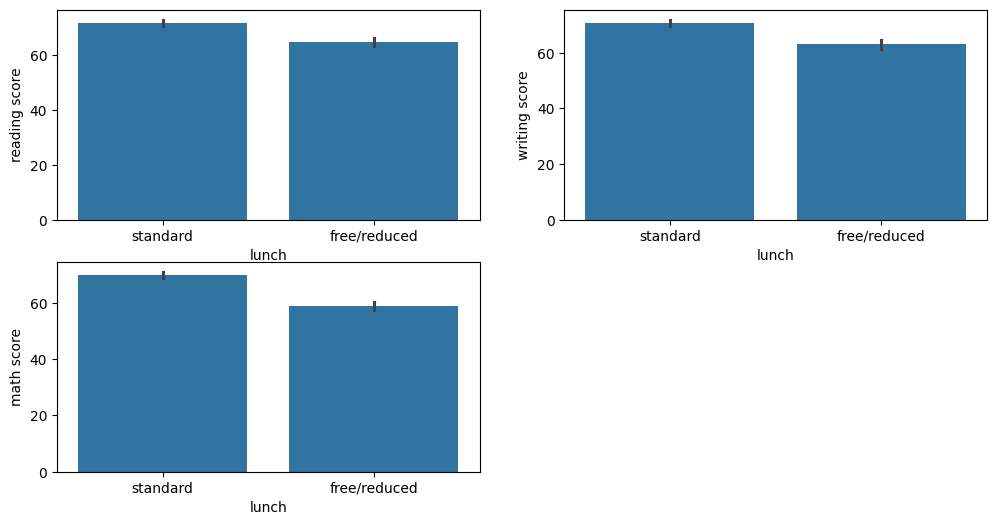

In [44]:
plt.figure(figsize = (12,6))
plt.subplot(2,2,1)
sns.barplot(x = df['lunch'] , y = df['reading score'])
plt.subplot(2,2,2)
sns.barplot(x = df['lunch'] , y = df['writing score'])
plt.subplot(2,2,3)
sns.barplot(x = df['lunch'] , y = df['math score'])
plt.show()